In [1]:
import pandas as pd

In [2]:
# Read the data 
df = pd.read_excel("data/Marklist.xlsx", header=None)

# Extract the required data from the excel sheet.
df.columns = df.iloc[7] # header
df = df.iloc[8:72] # content
df.columns = df.columns.astype(str).str.strip()
df = df.reset_index(drop=True)
df.columns.name = None

In [3]:
df.head() # reference

,S.No,Register Number,NAME,21CE501,21EE501,21EE521,21EE502,21EC521,21PEE02,21PEE06,21EN501,21EC521,21EE512,SGPA,No.of Arr,Pass/Fail,Rank
0,1,714023105001,ABHIRAG K,u,u,u,A,u,u,u,A,B+,B+,NaN,NaN,NaN,NaN
1,2,714023105002,ABHIROOPA R R,A,A,A,A,A,A,A,A+,A,O,8.12,0,Pass,NaN
2,3,714023105003,ABISHEK V,O,A+,A+,A,O,A,A+,A+,O,O,9.08,0,Pass,NaN
3,4,714023105004,AKSHAY K,A+,A,A+,A,A,A+,O,A+,B+,O,8.68,0,PASS,NaN
4,5,714023105005,ARCHANADEVI C,O,A,A+,A+,A,A+,O,O,A+,O,9,NaN,NaN,NaN


In [4]:
df.columns # reference

Index(['S.No', 'Register Number', 'NAME', '21CE501', '21EE501', '21EE521',
       '21EE502', '21EC521', '21PEE02', '21PEE06', '21EN501', '21EC521',
       '21EE512', 'SGPA', 'No.of Arr', 'Pass/Fail', 'Rank'],
      dtype='object')

In [5]:
# checking for inconsistencies and NaN handling.
df["SGPA"] = pd.to_numeric(df["SGPA"],errors="coerce")
df["SGPA"].isna().sum()

20

In [6]:
df = df.copy()

# Create response flag safely
df.loc[:, "Responded"] = df["SGPA"].notna()

# Split without overwriting df
responded_df = df[df["Responded"] == True]
non_responded_df = df[df["Responded"] == False]

# Total 64 students
print("Responded:", len(responded_df)) # 44 filled the sheet
print("Not Responded:", len(non_responded_df)) # 20 not filled
responded_df["SGPA"].isna().sum() # 0 - No inconsistencies => After handling the inconsistencies

Responded: 44
Not Responded: 20


0

In [7]:
# Handling Inconsistencies in subject scores

# Only extracting the subject columns.
non_subject_cols = [
    "S.No", "Register Number", "NAME",
    "SGPA", "No.of Arr", "Pass/Fail", "Rank", "Responded"
]

subject_cols = [col for col in df.columns if col not in non_subject_cols]
df = df.copy()

df["No.of Arr"] = df[subject_cols].apply(
    lambda row: (row.astype(str).str.upper() == 'U').sum(),
    axis = 1
)

# Filling all the Non-filled columns.
df.loc[df["No.of Arr"] > 0, "SGPA"] = pd.NA
df.loc[df["No.of Arr"] == 0, "Pass/Fail"] = "Pass"
df.loc[df["No.of Arr"] > 0, "Pass/Fail"] = "Fail"

# Ranking the students based on SGPA
df["Rank"] = pd.NA

df.loc[df["No.of Arr"] == 0, "Rank"] = (
    df.loc[df["No.of Arr"] == 0, "SGPA"]
      .rank(ascending=False, method="dense")
      .astype("Int64")   
)


In [8]:
df # reference

,S.No,Register Number,NAME,21CE501,21EE501,21EE521,21EE502,21EC521,21PEE02,21PEE06,21EN501,21EC521,21EE512,SGPA,No.of Arr,Pass/Fail,Rank,Responded
0,1,714023105001,ABHIRAG K,u,u,u,A,u,u,u,A,B+,B+,NaN,7,Fail,<NA>,False
1,2,714023105002,ABHIROOPA R R,A,A,A,A,A,A,A,A+,A,O,8.12,0,Pass,17,True
2,3,714023105003,ABISHEK V,O,A+,A+,A,O,A,A+,A+,O,O,9.08,0,Pass,2,True
3,4,714023105004,AKSHAY K,A+,A,A+,A,A,A+,O,A+,B+,O,8.68,0,Pass,8,True
4,5,714023105005,ARCHANADEVI C,O,A,A+,A+,A,A+,O,O,A+,O,9.00,0,Pass,3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,714023105301,HARRISH. A.B.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Pass,<NA>,False
60,61,714023105302,JANA. A,A,C,B+,B,A,B,B+,A,A,A,6.60,0,Pass,26,True
61,62,714023105303,PRAVEEN RAJ. E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Pass,<NA>,False
62,63,714023105304,SANTHOSH. M,A,B,A,B+,U,B,B+,A,A,A+,NaN,2,Fail,<NA>,True


In [9]:
# segreggating students eligible for ranking
rank_base = responded_df[responded_df["No.of Arr"] == 0].copy()
rank_base["Rank"] = (
    rank_base["SGPA"]
    .rank(ascending=False, method="dense")
    .astype("Int64")
)

df["Rank"] = pd.NA

df.loc[rank_base.index,"Rank"] = rank_base["Rank"]

df_sorted = df.sort_values(
    by = "Rank",
    ascending = True,
    na_position = "last",
).reset_index(drop = True)
df_sorted[["NAME", "SGPA", "No.of Arr", "Responded", "Rank"]].head(10)

,NAME,SGPA,No.of Arr,Responded,Rank
0,DAISY PANIMARIYAL J,9.32,0,True,1
1,ABISHEK V,9.08,0,True,2
2,SRI LAKSHYA S,8.88,0,True,3
3,THARANITHARAN M,8.84,0,True,4
4,KARTHIKA SREE V K,8.76,0,True,5
5,HARINI A.K,8.76,0,True,5
6,DHARSHINI S,8.72,0,True,6
7,SUBASH. K,8.72,0,True,6
8,VISHALI R,8.68,0,True,7
9,AKSHAY K,8.68,0,True,7


In [10]:
with open("output/ranked_list.csv","w",encoding="utf-8") as f:
    f.write(",".join(df_sorted.columns) + "\n")
    for i, row in df_sorted.iterrows():
        f.write(",".join(map(str,row.values)) + "\n")

In [11]:
# top 10 rank holders
top_10 = df_sorted[df_sorted["Rank"].notna()].head(10)

top_10[[
    "Rank",
    "Register Number",
    "NAME",
    "SGPA",
    "No.of Arr"
]]

,Rank,Register Number,NAME,SGPA,No.of Arr
0,1,714023105013,DAISY PANIMARIYAL J,9.32,0
1,2,714023105003,ABISHEK V,9.08,0
2,3,714023105051,SRI LAKSHYA S,8.88,0
3,4,714023105054,THARANITHARAN M,8.84,0
4,5,714023105025,KARTHIKA SREE V K,8.76,0
5,5,714023105019,HARINI A.K,8.76,0
6,6,714023105016,DHARSHINI S,8.72,0
7,6,714023105305,SUBASH. K,8.72,0
8,7,714023105058,VISHALI R,8.68,0
9,7,714023105004,AKSHAY K,8.68,0


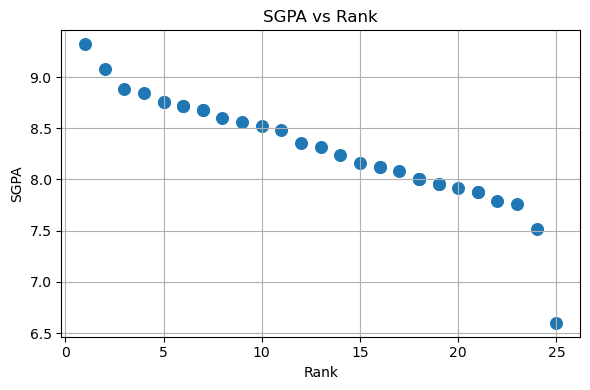

In [13]:
# Rank vs SGPA analysis

import matplotlib.pyplot as plt
rank_only = df_sorted[df_sorted["Rank"].notna()]
plt.figure(figsize=(6,4))
plt.scatter(rank_only["Rank"],rank_only["SGPA"],s=70)
plt.xlabel("Rank")
plt.ylabel("SGPA")
plt.title("SGPA vs Rank")
plt.grid(True)
plt.tight_layout()
plt.show()

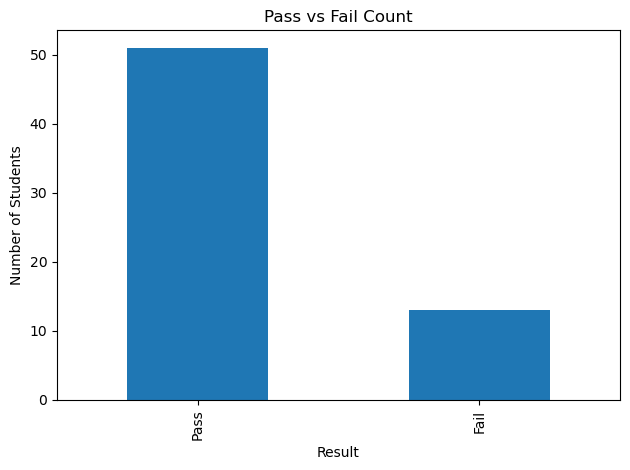

In [14]:
# calculating the pass fail frequencies using bar chat.
df["Pass/Fail"].value_counts().plot(kind="bar")

plt.title("Pass vs Fail Count")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

In [15]:
# Arrear per subject
arrear_by_subject = (
    df[subject_cols]
    .apply(lambda col: (col.astype(str).str.upper() == "U").sum())
    .sort_values(ascending=False)
)

arrear_by_subject # reference

21EC521    8
21EC521    8
21EE501    6
21EE521    5
21PEE02    3
21PEE06    2
21CE501    1
21EE502    0
21EC521    0
21EN501    0
21EC521    0
21EE512    0
dtype: int64

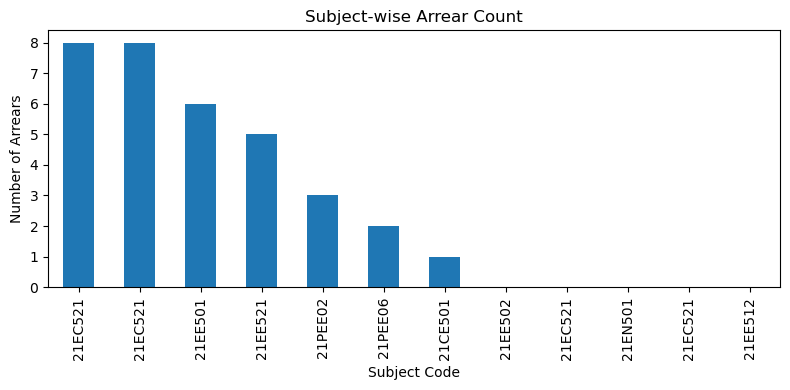

In [16]:
# ploting the number of arrears 
arrear_by_subject.plot(kind="bar", figsize=(8,4))

plt.title("Subject-wise Arrear Count")
plt.xlabel("Subject Code")
plt.ylabel("Number of Arrears")
plt.tight_layout()
plt.show()

In [17]:
arrear_by_subject = (
    df[subject_cols]
    .apply(lambda col: (col.astype(str).str.upper() == "U").sum())
)

In [ ]:
with open("output/subject_analysis/subject_wise_failures.csv", "w", encoding="utf-8") as f:
    f.write("Subject,Failure_Count\n")
    for subject, count in arrear_by_subject.items():
        f.write(f"{subject},{count}\n")

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(arrear_by_subject.index, arrear_by_subject.values)
plt.xlabel("Subject")
plt.ylabel("Number of Failures")
plt.title("Subject-wise Failure Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("output/subject_analysis/subject_wise_failures.png")
plt.close()